# Improvements Summary

- **First improvement:** Temporal encoding for longitudinal visit timing.
- **Second improvement:** ALiBi (temporal attention bias) in transformer attention.

## Comparison

| Metric | Baseline | Temporal | ALiBi | Δ (Second - First) |
|---|---:|---:|---:|---:|
| C-index | 0.751979 | 0.766491 | 0.777045 | +0.010554 |
| AUC@2y | 0.919276 | 0.925935 | 0.958218 | +0.032283 |
| AUC@3y | 0.692600 | 0.728624 | 0.745732 | +0.017108 |
| AUC@5y | 0.749576 | 0.731835 | 0.740476 | +0.008641 |
| Binary AUC | 0.737179 | 0.740385 | 0.753205 | +0.012820 |

In [1]:
!pip install lifelines scikit-survival

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 17.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=12f9c04bead6968b5990f5eaf9ab9862b0932f7febca9dd3456d2016b8730092
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import json
import os
import random
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines.utils import concordance_index
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

CONFIG = {
    'converters_root': r'/kaggle/input/datasets/ahmadsarfraz345/adni-final/converters/converters',
    'stable_root': r'/kaggle/input/datasets/ahmadsarfraz345/adni-final/stable/stable',
    'converter_time_csv': r'/kaggle/input/datasets/ahmadsarfraz345/adni-final/convertors.csv',
    'output_dir': 'baseline_outputs',
    'd_model': 128,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 256,
    'dropout': 0.1,
    'batch_size': 4,
    'num_epochs': 30,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'early_stop_patience': 30,
    'volume_size': 96,
    'max_visits': 4,
    'seed': 42,
    'train_frac': 0.70,
    'val_frac': 0.15,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'use_data_parallel': True,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
n_cuda = torch.cuda.device_count()
print(f"Running on device: {CONFIG['device']}")
print(f"Visible CUDA GPUs: {n_cuda}")

Running on device: cuda
Visible CUDA GPUs: 2


## Section 1: Data Loading and Label Construction

This section loads longitudinal MRI series directly from the local DICOM directory structure. Subjects are collected from separate converters and stable cohorts, visits are ordered by acquisition date parsed from folder names (or DICOM headers as fallback), and survival targets are built at subject level for training.

In [3]:
MCI_FAMILY = {'MCI', 'EMCI', 'LMCI'}
SUBJECT_PATTERN = re.compile(r'^\d{3}_S_\d{4}$')
IMAGE_ID_PATTERN = re.compile(r'^I\d+$')
DATE_TOKEN_PATTERN = re.compile(r'^\d{4}-\d{2}-\d{2}_')


def parse_date_from_token(token):
    if token is None:
        return None
    prefix = str(token).split('_')[0]
    try:
        return datetime.strptime(prefix, '%Y-%m-%d')
    except ValueError:
        return None


def parse_date_from_dicom(series_dir):
    dcm_files = sorted(Path(series_dir).glob('*.dcm'))
    if len(dcm_files) == 0:
        return None
    try:
        ds = pydicom.dcmread(str(dcm_files[0]), stop_before_pixels=True, force=True)
    except Exception:
        return None

    for attr in ['AcquisitionDate', 'StudyDate', 'SeriesDate', 'ContentDate']:
        raw_date = getattr(ds, attr, None)
        if raw_date:
            parsed = pd.to_datetime(str(raw_date), format='%Y%m%d', errors='coerce')
            if not pd.isna(parsed):
                return parsed.to_pydatetime()
    return None


def find_series_dirs(subject_dir):
    series_dirs = []
    for p in Path(subject_dir).rglob('*'):
        if p.is_dir() and IMAGE_ID_PATTERN.match(p.name):
            if len(list(p.glob('*.dcm'))) > 0:
                series_dirs.append(p)
    return sorted(series_dirs)


def extract_research_group(xml_path):
    text = Path(xml_path).read_text(encoding='utf-8', errors='ignore')
    match = re.search(r'<researchGroup>([^<]+)</researchGroup>', text)
    if match:
        return match.group(1).strip().upper()
    return None


def load_converter_time_map(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Converter time CSV not found: {csv_path}. "
            "Set CONFIG['converter_time_csv'] to your Kaggle file path."
        )

    conv_df = pd.read_csv(csv_path)
    required_cols = {'Subject', 'Time_To_Conversion_Days'}
    missing_cols = required_cols.difference(conv_df.columns)
    if missing_cols:
        raise ValueError(
            f"Missing required columns in converter CSV: {sorted(missing_cols)}. "
            f"Found columns: {list(conv_df.columns)}"
        )

    conv_df = conv_df[['Subject', 'Time_To_Conversion_Days']].copy()
    conv_df['Subject'] = conv_df['Subject'].astype(str).str.strip()
    conv_df['Time_To_Conversion_Days'] = pd.to_numeric(conv_df['Time_To_Conversion_Days'], errors='coerce')
    conv_df = conv_df.dropna(subset=['Subject', 'Time_To_Conversion_Days'])

    conv_df = conv_df.drop_duplicates(subset=['Subject'], keep='first')

    conv_time_map = {
        sid: float(ttc)
        for sid, ttc in zip(conv_df['Subject'], conv_df['Time_To_Conversion_Days'])
        if float(ttc) > 0
    }
    print(f"Loaded converter ground-truth times: {len(conv_time_map)} subjects from {csv_path}")
    return conv_time_map


def build_subject_records(cohort_root, cohort_name, label, event, converter_time_map=None):
    cohort_root = Path(cohort_root)
    adni_root = cohort_root / 'ADNI'
    meta_root = cohort_root / 'metadata' / 'ADNI'

    if not adni_root.exists():
        print(f"WARNING: Missing ADNI directory for cohort={cohort_name}: {adni_root}")
        return []

    metadata_groups = []
    if meta_root.exists():
        for xml_file in meta_root.rglob('*.xml'):
            grp = extract_research_group(xml_file)
            if grp is not None:
                metadata_groups.append(grp)
    if len(metadata_groups) > 0:
        grp_counts = pd.Series(metadata_groups).value_counts().to_dict()
        print(f"{cohort_name} metadata group counts: {grp_counts}")

    subject_records = []
    skipped_subjects_few_visits = 0
    skipped_series_missing_date = 0
    converter_time_fallbacks = 0

    subject_dirs = [p for p in adni_root.iterdir() if p.is_dir() and SUBJECT_PATTERN.match(p.name)]
    for subject_dir in sorted(subject_dirs):
        subject_id = subject_dir.name
        series_rows = []

        for series_dir in find_series_dirs(subject_dir):
            image_id = series_dir.name
            date_obj = parse_date_from_token(series_dir.parent.name)
            if date_obj is None:
                date_obj = parse_date_from_dicom(series_dir)

            if date_obj is None:
                skipped_series_missing_date += 1
                print(f"WARNING: Missing acquisition date for subject={subject_id}, image_id={image_id}. Skipping series.")
                continue

            series_rows.append({
                'date': date_obj,
                'image_id': image_id,
                'series_dir': series_dir,
            })

        if len(series_rows) < 4:
            skipped_subjects_few_visits += 1
            continue

        series_rows.sort(key=lambda x: (x['date'], x['image_id']))
        visit_dates = [r['date'] for r in series_rows]
        image_ids = [r['image_id'] for r in series_rows]
        series_dirs = [r['series_dir'] for r in series_rows]

        scan_span_days = float((visit_dates[-1] - visit_dates[0]).days)

        if cohort_name == 'converters':
            ttc = None if converter_time_map is None else converter_time_map.get(subject_id)
            if ttc is None:
                converter_time_fallbacks += 1
                time_to_event = scan_span_days
            else:
                time_to_event = float(ttc)
        else:
            time_to_event = scan_span_days

        if time_to_event <= 0:
            time_to_event = 1.0

        subject_records.append({
            'subject_id': subject_id,
            'visit_dates': visit_dates,
            'image_ids': image_ids,
            'series_dirs': series_dirs,
            'label': int(label),
            'event': int(event),
            'time_to_event': float(time_to_event),
            'cohort': cohort_name,
        })

    print(f"{cohort_name}: retained subjects={len(subject_records)}, skipped subjects (<4 usable visits)={skipped_subjects_few_visits}, skipped series (missing date)={skipped_series_missing_date}")
    if cohort_name == 'converters':
        print(f"{cohort_name}: used CSV ground-truth time for {len(subject_records) - converter_time_fallbacks} subjects; fallback to scan span for {converter_time_fallbacks} subjects")
    return subject_records


converter_time_map = load_converter_time_map(CONFIG['converter_time_csv'])

converter_subjects = build_subject_records(
    cohort_root=CONFIG['converters_root'],
    cohort_name='converters',
    label=1,
    event=1,
    converter_time_map=converter_time_map,
)

stable_subjects = build_subject_records(
    cohort_root=CONFIG['stable_root'],
    cohort_name='stable',
    label=0,
    event=0,
)

subjects = converter_subjects + stable_subjects

if len(subjects) == 0:
    raise RuntimeError('No usable subjects found. Check converters/stable folder structure and DICOM contents.')

num_subjects = len(subjects)
num_converters = int(sum(s['label'] for s in subjects))
num_stable = num_subjects - num_converters
visits_per_subject = [len(s['series_dirs']) for s in subjects]
avg_visits = float(np.mean(visits_per_subject)) if visits_per_subject else 0.0
min_visits = int(np.min(visits_per_subject)) if visits_per_subject else 0
max_visits = int(np.max(visits_per_subject)) if visits_per_subject else 0

conv_pct = (100.0 * num_converters / num_subjects) if num_subjects > 0 else 0.0
stable_pct = (100.0 * num_stable / num_subjects) if num_subjects > 0 else 0.0

print(f"Total subjects retained: {num_subjects}")
print(f"Converters (pMCI):       {num_converters}  ({conv_pct:.2f}%)")
print(f"Stable (sMCI):           {num_stable}  ({stable_pct:.2f}%)")
print(f"Avg visits per subject:  {avg_visits:.2f}")
print(f"Min/Max visits:          {min_visits} / {max_visits}")

if num_converters == 0 or num_stable == 0:
    print('WARNING: Only one class detected after loading. Training and evaluation require both converter and stable subjects.')

subject_preview = pd.DataFrame([
    {
        'subject_id': s['subject_id'],
        'cohort': s['cohort'],
        'n_visits': len(s['series_dirs']),
        'first_date': s['visit_dates'][0].strftime('%Y-%m-%d'),
        'last_date': s['visit_dates'][-1].strftime('%Y-%m-%d'),
        'label': s['label'],
        'time_to_event_days': s['time_to_event'],
    }
    for s in subjects
]).sort_values(['cohort', 'subject_id']).reset_index(drop=True)

display(subject_preview.head(20))

Loaded converter ground-truth times: 160 subjects from /kaggle/input/datasets/ahmadsarfraz345/adni-final/convertors.csv
converters: retained subjects=155, skipped subjects (<4 usable visits)=5, skipped series (missing date)=0
converters: used CSV ground-truth time for 153 subjects; fallback to scan span for 2 subjects
stable metadata group counts: {'EMCI': 819, 'MCI': 430, 'LMCI': 269}
stable: retained subjects=256, skipped subjects (<4 usable visits)=22, skipped series (missing date)=0
Total subjects retained: 411
Converters (pMCI):       155  (37.71%)
Stable (sMCI):           256  (62.29%)
Avg visits per subject:  6.01
Min/Max visits:          4 / 17


,subject_id,cohort,n_visits,first_date,last_date,label,time_to_event_days
0,002_S_0729,converters,4,2009-08-13,2013-08-16,1,418.0
1,002_S_1070,converters,8,2007-12-10,2009-12-10,1,635.0
2,002_S_4171,converters,8,2011-08-08,2012-08-24,1,944.0
3,002_S_4521,converters,7,2012-02-17,2016-03-24,1,1106.0
4,002_S_4746,converters,8,2012-05-29,2013-06-03,1,1197.0
5,003_S_1057,converters,7,2006-12-04,2012-03-08,1,755.0
6,003_S_1074,converters,8,2006-12-04,2013-07-29,1,3338.0
7,003_S_1122,converters,11,2006-12-06,2014-01-27,1,6745.0
8,006_S_4346,converters,8,2011-11-10,2012-11-27,1,1169.0
9,006_S_4363,converters,5,2011-11-16,2014-01-10,1,1153.0


In [4]:
if len(subjects) < 3:
    raise RuntimeError('Not enough subjects to perform train/val/test split.')

subject_labels = [s['label'] for s in subjects]
label_counts = pd.Series(subject_labels).value_counts().to_dict()
print(f"Label counts before split: {label_counts}")


def split_subjects_by_label(subjects, train_frac, val_frac, seed):
    rng = np.random.default_rng(seed)
    by_label = {}
    for s in subjects:
        by_label.setdefault(int(s['label']), []).append(s)

    train_split, val_split, test_split = [], [], []

    for label, items in by_label.items():
        items = list(items)
        rng.shuffle(items)
        n = len(items)

        if n == 1:
            train_n, val_n, test_n = 1, 0, 0
        elif n == 2:
            train_n, val_n, test_n = 1, 0, 1
        else:
            train_n = int(round(train_frac * n))
            val_n = int(round(val_frac * n))

            train_n = max(1, train_n)
            val_n = max(1, val_n)
            test_n = n - train_n - val_n

            if test_n < 1:
                if train_n > val_n and train_n > 1:
                    train_n -= 1
                elif val_n > 1:
                    val_n -= 1
                test_n = n - train_n - val_n

            if val_n < 1 and n >= 3:
                if train_n > 1:
                    train_n -= 1
                    val_n += 1
                elif test_n > 1:
                    test_n -= 1
                    val_n += 1

            test_n = n - train_n - val_n
            if train_n < 1 or test_n < 1:
                train_n = max(1, min(train_n, n - 2))
                val_n = max(1, min(val_n, n - train_n - 1))
                test_n = n - train_n - val_n

        train_split.extend(items[:train_n])
        val_split.extend(items[train_n:train_n + val_n])
        test_split.extend(items[train_n + val_n:train_n + val_n + test_n])

    rng.shuffle(train_split)
    rng.shuffle(val_split)
    rng.shuffle(test_split)
    return train_split, val_split, test_split


train_subjects, val_subjects, test_subjects = split_subjects_by_label(
    subjects=subjects,
    train_frac=CONFIG['train_frac'],
    val_frac=CONFIG['val_frac'],
    seed=CONFIG['seed']
)

train_ids = {s['subject_id'] for s in train_subjects}
val_ids = {s['subject_id'] for s in val_subjects}
test_ids = {s['subject_id'] for s in test_subjects}

assert len(train_ids.intersection(val_ids)) == 0, 'Leakage detected: train ∩ val is not empty'
assert len(train_ids.intersection(test_ids)) == 0, 'Leakage detected: train ∩ test is not empty'
assert len(val_ids.intersection(test_ids)) == 0, 'Leakage detected: val ∩ test is not empty'

print('## Section 2: Train/Val/Test Split')
print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects:   {len(val_subjects)}")
print(f"Test subjects:  {len(test_subjects)}")


def split_stats(split_name, split_subjects):
    labels = np.array([s['label'] for s in split_subjects])
    rate = labels.mean() * 100 if len(labels) > 0 else 0.0
    n_events = int(np.sum([s['event'] for s in split_subjects]))
    print(f"{split_name} converter rate: {rate:.2f}% ({labels.sum()}/{len(labels)}) | events={n_events}")


split_stats('Train', train_subjects)
split_stats('Val', val_subjects)
split_stats('Test', test_subjects)

if len(val_subjects) < 3 or len(test_subjects) < 3:
    print('WARNING: Very small validation/test splits may make C-index unstable (NaN possible).')

Label counts before split: {0: 256, 1: 155}
## Section 2: Train/Val/Test Split
Train subjects: 287
Val subjects:   61
Test subjects:  63
Train converter rate: 37.63% (108/287) | events=108
Val converter rate: 37.70% (23/61) | events=23
Test converter rate: 38.10% (24/63) | events=24


## Section 3: Dataset and DataLoader

This section defines a memory-safe lazy-loading dataset for longitudinal DICOM MRI series. Each visit is reconstructed from sorted DICOM slices into a 3D volume, centre-cropped per sample, normalised independently per volume, and collated with sequence padding plus a transformer-compatible padding mask.

In [5]:
class ADNILongitudinalDataset(Dataset):
    def __init__(self, subject_list, volume_size=96, max_visits=6, augment=False):
        self.subject_list = subject_list
        self.volume_size = volume_size
        self.max_visits = max_visits
        self.augment = augment

    def __len__(self):
        return len(self.subject_list)

    def _resolve_slice_order(self, ds, dcm_path):
        instance_no = getattr(ds, 'InstanceNumber', None)
        if instance_no is not None:
            try:
                return (0, float(instance_no))
            except Exception:
                pass

        ipp = getattr(ds, 'ImagePositionPatient', None)
        if ipp is not None and len(ipp) >= 3:
            try:
                return (0, float(ipp[2]))
            except Exception:
                pass

        return (1, str(dcm_path.name))

    def _extract_2d_slices(self, arr):
        arr = np.asarray(arr, dtype=np.float32)
        arr = np.squeeze(arr)

        if arr.ndim == 2:
            return [arr]

        if arr.ndim == 3:
            if arr.shape[0] <= min(arr.shape[1], arr.shape[2]):
                return [arr[i] for i in range(arr.shape[0])]

            if arr.shape[-1] <= min(arr.shape[0], arr.shape[1]):
                return [arr[..., i] for i in range(arr.shape[-1])]

            return [arr[i] for i in range(arr.shape[0])]

        raise RuntimeError(f'Unsupported DICOM pixel array shape: {arr.shape}')

    def _load_dicom_volume(self, series_dir):
        dcm_paths = sorted(Path(series_dir).glob('*.dcm'))
        if len(dcm_paths) == 0:
            raise RuntimeError(f'No DICOM files found in series: {series_dir}')

        slices = []
        for dcm_path in dcm_paths:
            ds = pydicom.dcmread(str(dcm_path), force=True)
            arr = ds.pixel_array.astype(np.float32)

            slope = float(getattr(ds, 'RescaleSlope', 1.0))
            intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
            arr = arr * slope + intercept

            base_order = self._resolve_slice_order(ds, dcm_path)
            for frame_idx, frame_arr in enumerate(self._extract_2d_slices(arr)):
                slices.append(((base_order[0], base_order[1], frame_idx), frame_arr))

        if len(slices) == 0:
            raise RuntimeError(f'No usable slices extracted in series: {series_dir}')

        slices.sort(key=lambda x: x[0])

        shapes = [s[1].shape for s in slices]
        if len(set(shapes)) > 1:
            min_h = min(shape[0] for shape in shapes)
            min_w = min(shape[1] for shape in shapes)
            clipped = [s[1][:min_h, :min_w] for s in slices]
        else:
            clipped = [s[1] for s in slices]

        volume = np.stack(clipped, axis=-1)
        if volume.ndim != 3:
            raise RuntimeError(f'Expected 3D volume, got shape={volume.shape} for series={series_dir}')

        return volume

    def _center_crop(self, vol):
        if vol.ndim != 3:
            raise RuntimeError(f'_center_crop expects 3D volume, got shape={vol.shape}')

        target = self.volume_size
        pad_width = []
        for dim in vol.shape:
            if dim < target:
                total_pad = target - dim
                left = total_pad // 2
                right = total_pad - left
                pad_width.append((left, right))
            else:
                pad_width.append((0, 0))

        if any(p != (0, 0) for p in pad_width):
            vol = np.pad(vol, pad_width=pad_width, mode='constant', constant_values=0)

        starts = [int((dim - target) // 2) for dim in vol.shape]
        ends = [s + target for s in starts]
        return vol[starts[0]:ends[0], starts[1]:ends[1], starts[2]:ends[2]]

    def __getitem__(self, idx):
        subject = self.subject_list[idx]
        series_dirs = subject['series_dirs'][:self.max_visits]

        scans = []
        for series_dir in series_dirs:
            vol = self._load_dicom_volume(series_dir)
            vol = self._center_crop(vol)

            vol_mean = float(vol.mean())
            vol_std = float(vol.std())
            vol = (vol - vol_mean) / (vol_std + 1e-8)

            if self.augment and random.random() < 0.5:
                vol = np.flip(vol, axis=0).copy()

            vol = np.expand_dims(vol, axis=0)
            scans.append(torch.from_numpy(vol).float())

        scans = torch.stack(scans, dim=0)
        visit_dates = subject['visit_dates'][:self.max_visits]
        anchor = visit_dates[0]
        elapsed_years = torch.tensor(
            [(d - anchor).days / 365.25 for d in visit_dates],
            dtype=torch.float32
        )

        return {
            'scans': scans,
            'elapsed_years': elapsed_years,
            'label': int(subject['label']),
            'time_to_event': float(subject['time_to_event']),
            'event': int(subject['event']),
            'subject_id': subject['subject_id'],
        }


def collate_fn(batch):
    batch_size = len(batch)
    max_t = max(item['scans'].shape[0] for item in batch)
    volume_size = batch[0]['scans'].shape[-1]

    scans = torch.zeros((batch_size, max_t, 1, volume_size, volume_size, volume_size), dtype=torch.float32)
    elapsed_years = torch.zeros((batch_size, max_t), dtype=torch.float32)
    padding_mask = torch.ones((batch_size, max_t), dtype=torch.bool)

    labels = []
    time_to_event = []
    event = []
    subject_id = []

    for i, item in enumerate(batch):
        t = item['scans'].shape[0]
        scans[i, :t] = item['scans']
        elapsed_years[i, :t] = item['elapsed_years']
        padding_mask[i, :t] = False

        labels.append(item['label'])
        time_to_event.append(item['time_to_event'])
        event.append(item['event'])
        subject_id.append(item['subject_id'])

    return {
        'scans': scans,
        'elapsed_years': elapsed_years,
        'padding_mask': padding_mask,
        'label': torch.tensor(labels, dtype=torch.float32),
        'time_to_event': torch.tensor(time_to_event, dtype=torch.float32),
        'event': torch.tensor(event, dtype=torch.float32),
        'subject_id': subject_id,
    }


train_dataset = ADNILongitudinalDataset(
    train_subjects,
    volume_size=CONFIG['volume_size'],
    max_visits=CONFIG['max_visits'],
    augment=True
)
val_dataset = ADNILongitudinalDataset(
    val_subjects,
    volume_size=CONFIG['volume_size'],
    max_visits=CONFIG['max_visits'],
    augment=False
)
test_dataset = ADNILongitudinalDataset(
    test_subjects,
    volume_size=CONFIG['volume_size'],
    max_visits=CONFIG['max_visits'],
    augment=False
)

pin_memory = CONFIG['device'] == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=pin_memory,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 72
Val batches:   16
Test batches:  16


## Section 4: Model Architecture

The baseline model combines a 3D CNN encoder (per visit) with a Transformer encoder over ordered visit tokens. Positional information is standard sinusoidal encoding over visit index only, with no gap-aware logic. A learnable CLS token aggregates sequence context for subject-level log-risk prediction through a linear Cox risk head.

In [6]:
class CNN3DEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d(1),
        )
        self.proj = nn.Linear(256, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        x = self.proj(x)
        return x

class ContinuousTimeEncoding(nn.Module):
    def __init__(self, d_model=128, max_years=10):
        super().__init__()
        half = d_model // 2
        div_term = torch.exp(
            torch.arange(0, half, 2, dtype=torch.float32)
            * (-np.log(10000.0) / half)
        )
        self.register_buffer('div_term', div_term)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        nn.init.eye_(self.proj.weight)
        self.norm = nn.LayerNorm(d_model)

    def _sinusoidal(self, t_scalar):
        div = self.div_term.view(1, 1, -1)
        half_d = self.div_term.shape[0] * 2
        pe = torch.zeros(*t_scalar.shape[:2], half_d, device=t_scalar.device)
        pe[:, :, 0::2] = torch.sin(t_scalar * div)
        pe[:, :, 1::2] = torch.cos(t_scalar * div)
        return pe

    def forward(self, elapsed_years):
        gaps = torch.zeros_like(elapsed_years)
        gaps[:, 1:] = elapsed_years[:, 1:] - elapsed_years[:, :-1]

        abs_pe = self._sinusoidal(elapsed_years.unsqueeze(-1))
        gap_pe = self._sinusoidal(gaps.unsqueeze(-1))
        pe = torch.cat([abs_pe, gap_pe], dim=-1)
        return self.norm(self.proj(pe))


class AttnBiasTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, src, src_key_padding_mask=None, attn_bias=None):
        attn_output, _ = self.self_attn(
            src,
            src,
            src,
            attn_mask=attn_bias,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
        )
        src = self.norm1(src + self.dropout1(attn_output))

        ff = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = self.norm2(src + self.dropout2(ff))
        return src


class AttnBiasTransformerEncoder(nn.Module):
    def __init__(self, d_model, nhead, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            AttnBiasTransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

    def forward(self, src, src_key_padding_mask=None, attn_bias=None):
        x = src
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask, attn_bias=attn_bias)
        return x


class LongitudinalTransformerBaseline(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.encoder = CNN3DEncoder(out_dim=d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_encoder = ContinuousTimeEncoding(d_model=d_model, max_years=10)

        self.nhead = nhead
        max_slope, min_slope = 4.0, 0.5
        slope_init = torch.exp(torch.linspace(np.log(max_slope), np.log(min_slope), nhead, dtype=torch.float32))
        self.slopes = nn.Parameter(slope_init)

        self.transformer = AttnBiasTransformerEncoder(
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.risk_head = nn.Linear(d_model, 1)

    def _encode_sequence(self, batch):
        scans = batch['scans']
        elapsed_years = batch['elapsed_years']
        padding_mask = batch['padding_mask']

        batch_size, seq_len = scans.shape[0], scans.shape[1]

        tokens = []
        for t in range(seq_len):
            token_t = self.encoder(scans[:, t])
            tokens.append(token_t)
        x = torch.stack(tokens, dim=1)

        x = x + self.pos_encoder(elapsed_years)
        pad_mask_expanded = padding_mask.unsqueeze(-1).float()
        x = x * (1.0 - pad_mask_expanded)

        cls = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls, x], dim=1)

        cls_mask = torch.zeros((batch_size, 1), dtype=torch.bool, device=padding_mask.device)
        src_key_padding_mask = torch.cat([cls_mask, padding_mask], dim=1)

        gaps = torch.abs(elapsed_years.unsqueeze(2) - elapsed_years.unsqueeze(1))
        gaps_with_cls = torch.zeros(
            (batch_size, seq_len + 1, seq_len + 1),
            dtype=gaps.dtype,
            device=gaps.device,
        )
        gaps_with_cls[:, 1:, 1:] = gaps

        slopes_pos = torch.nn.functional.softplus(self.slopes)
        attn_bias = -slopes_pos.view(1, self.nhead, 1, 1) * gaps_with_cls.unsqueeze(1)
        attn_bias = attn_bias.reshape(batch_size * self.nhead, seq_len + 1, seq_len + 1)
        attn_bias = attn_bias.to(dtype=x.dtype)

        x = self.transformer(
            x,
            src_key_padding_mask=src_key_padding_mask,
            attn_bias=attn_bias,
        )
        cls_embedding = x[:, 0]
        return cls_embedding

    def forward(self, batch):
        cls_embedding = self._encode_sequence(batch)
        log_risk = self.risk_head(cls_embedding).squeeze(-1)
        return log_risk

    def forward_features(self, batch):
        return self._encode_sequence(batch)

def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def build_model(config):
    base_model = LongitudinalTransformerBaseline(
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_layers=config['num_layers'],
        dim_feedforward=config['dim_feedforward'],
        dropout=config['dropout']
    ).to(config['device'])

    n_cuda = torch.cuda.device_count() if config['device'] == 'cuda' else 0
    use_dp = bool(config.get('use_data_parallel', True)) and n_cuda > 1

    if use_dp:
        model = nn.DataParallel(base_model)
        print(f"Using DataParallel on {n_cuda} GPUs")
    else:
        model = base_model
        if n_cuda == 1:
            print('Using single GPU')
        else:
            print('Using CPU')

    return model

model = build_model(CONFIG)

base_model = unwrap_model(model)
param_count = sum(p.numel() for p in base_model.parameters())
trainable_param_count = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Total parameters: {param_count:,}")
print(f"Trainable parameters: {trainable_param_count:,}")

Using DataParallel on 2 GPUs
Total parameters: 1,478,277
Trainable parameters: 1,478,277


In [7]:
def cox_partial_likelihood_loss(log_risk, time_to_event, event):
    """
    log_risk:      (B,) tensor of predicted log-risk scores
    time_to_event: (B,) tensor of survival times
    event:         (B,) tensor of event indicators (1=converted, 0=censored)

    Returns scalar loss. If no events in batch, returns zero tensor.
    """
    event = event.bool()
    if event.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=log_risk.device)

    order = torch.argsort(time_to_event, descending=True)
    log_risk = log_risk[order]
    event = event[order]

    log_cumsum_exp = torch.logcumsumexp(log_risk, dim=0)
    loss = -torch.mean(log_risk[event] - log_cumsum_exp[event])
    return loss

## Section 6: Training Loop

This section trains the baseline with Cox partial likelihood, validates with C-index, applies checkpointing on best validation C-index, performs early stopping, and visualizes optimization curves.

Using DataParallel on 2 GPUs


Epoch 1/30 [train]:   0%|          | 0/72 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 001 | train_loss=0.7101 | val_loss=0.7555 | val_cindex=0.5375 | val_events=23


Epoch 2/30 [train]:   0%|          | 0/72 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 029 | train_loss=0.5918 | val_loss=0.5812 | val_cindex=0.7525 | val_events=23


Epoch 30/30 [train]:   0%|          | 0/72 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del

Epoch 030 | train_loss=0.7274 | val_loss=0.4771 | val_cindex=0.7550 | val_events=23


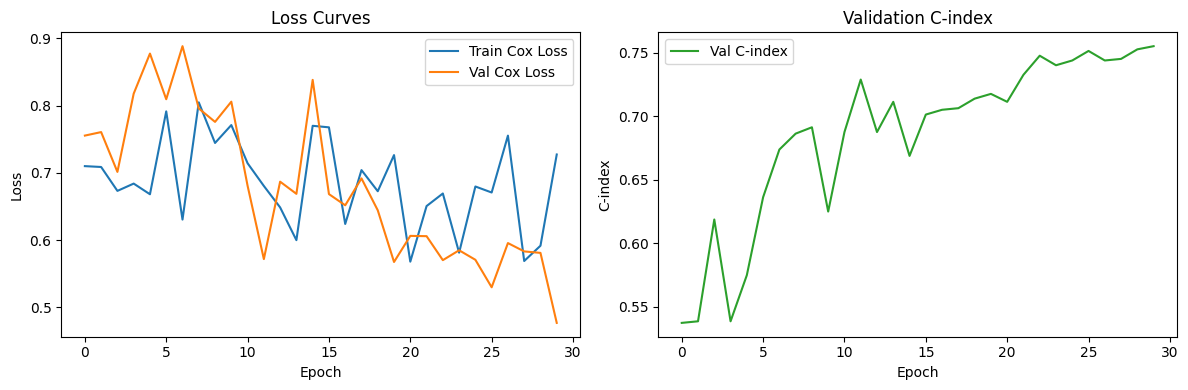

Best checkpoint: baseline_outputs/baseline_best.pt
Best validation C-index: 0.7550
Best fallback validation loss: inf


In [8]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CONFIG['seed'])

model = build_model(CONFIG)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)
warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'] - 3)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

best_val_cindex = -np.inf
best_val_loss_fallback = np.inf
epochs_without_improvement = 0
best_checkpoint_path = Path(CONFIG['output_dir']) / 'baseline_best.pt'

train_losses = []
val_losses = []
val_cindices = []


def compute_cindex(event_times_np, log_risk_np, event_np):
    if len(event_times_np) < 2:
        return np.nan
    if np.sum(event_np) == 0:
        return np.nan
    if len(np.unique(event_times_np)) < 2:
        return np.nan
    try:
        cidx = concordance_index(event_times_np, -log_risk_np, event_observed=event_np)
        return float(cidx)
    except Exception as ex:
        print(f"WARNING: C-index computation failed: {ex}")
        return np.nan


for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    epoch_train_losses = []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{CONFIG['num_epochs']} [train]", leave=False)
    for batch in train_bar:
        optimizer.zero_grad(set_to_none=True)

        batch_for_model = {
            'scans': batch['scans'].to(CONFIG['device']),
            'elapsed_years': batch['elapsed_years'].to(CONFIG['device']),
            'padding_mask': batch['padding_mask'].to(CONFIG['device']),
        }
        time_to_event = batch['time_to_event'].to(CONFIG['device'])
        event = batch['event'].to(CONFIG['device'])

        log_risk = model(batch_for_model)
        loss = cox_partial_likelihood_loss(log_risk, time_to_event, event)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['grad_clip'])
        optimizer.step()

        epoch_train_losses.append(float(loss.item()))
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    model.eval()
    epoch_val_losses = []
    val_event_times = []
    val_log_risks = []
    val_events = []

    with torch.no_grad():
        for batch in val_loader:
            batch_for_model = {
                'scans': batch['scans'].to(CONFIG['device']),
                'elapsed_years': batch['elapsed_years'].to(CONFIG['device']),
                'padding_mask': batch['padding_mask'].to(CONFIG['device']),
            }
            time_to_event = batch['time_to_event'].to(CONFIG['device'])
            event = batch['event'].to(CONFIG['device'])

            log_risk = model(batch_for_model)
            val_loss = cox_partial_likelihood_loss(log_risk, time_to_event, event)

            epoch_val_losses.append(float(val_loss.item()))
            val_event_times.extend(batch['time_to_event'].cpu().numpy().tolist())
            val_log_risks.extend(log_risk.detach().cpu().numpy().tolist())
            val_events.extend(batch['event'].cpu().numpy().tolist())

    train_loss_epoch = float(np.mean(epoch_train_losses)) if epoch_train_losses else np.nan
    val_loss_epoch = float(np.mean(epoch_val_losses)) if epoch_val_losses else np.nan
    val_cindex_epoch = compute_cindex(
        np.asarray(val_event_times, dtype=float),
        np.asarray(val_log_risks, dtype=float),
        np.asarray(val_events, dtype=int)
    )

    train_losses.append(train_loss_epoch)
    val_losses.append(val_loss_epoch)
    val_cindices.append(val_cindex_epoch)

    scheduler.step()

    improved = False
    monitor_name = None
    monitor_value = None

    if not np.isnan(val_cindex_epoch):
        if val_cindex_epoch > best_val_cindex:
            best_val_cindex = val_cindex_epoch
            improved = True
            monitor_name = 'val_cindex'
            monitor_value = val_cindex_epoch
    else:
        if np.isfinite(val_loss_epoch) and val_loss_epoch < best_val_loss_fallback:
            best_val_loss_fallback = val_loss_epoch
            improved = True
            monitor_name = 'val_loss_fallback'
            monitor_value = val_loss_epoch

    if improved:
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': unwrap_model(model).state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cindex': val_cindex_epoch,
            'val_loss': val_loss_epoch,
            'config': CONFIG,
            'monitor_name': monitor_name,
            'monitor_value': monitor_value,
        }, best_checkpoint_path)
    else:
        epochs_without_improvement += 1

    n_val_events = int(np.sum(np.asarray(val_events, dtype=int)))
    print(
        f"Epoch {epoch:03d} | train_loss={train_loss_epoch:.4f} | "
        f"val_loss={val_loss_epoch:.4f} | val_cindex={val_cindex_epoch:.4f} | "
        f"val_events={n_val_events}"
    )

    if np.isnan(val_cindex_epoch):
        print('INFO: Val C-index is NaN (too few admissible pairs). Using val loss fallback for checkpointing.')

    if epochs_without_improvement >= CONFIG['early_stop_patience']:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train Cox Loss')
axes[0].plot(val_losses, label='Val Cox Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(val_cindices, label='Val C-index', color='tab:green')
axes[1].set_title('Validation C-index')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('C-index')
axes[1].legend()

plt.tight_layout()
plot_path = Path(CONFIG['output_dir']) / 'training_curves.png'
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Best checkpoint: {best_checkpoint_path}")
print(f"Best validation C-index: {best_val_cindex:.4f}")
print(f"Best fallback validation loss: {best_val_loss_fallback:.4f}")

## Section 7: Evaluation

This section reloads the best checkpoint and evaluates test-set performance with C-index (primary), cumulative/dynamic AUC at fixed windows, and secondary classification-style metrics for paper comparability.

In [9]:
if not best_checkpoint_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found at {best_checkpoint_path}")

checkpoint = torch.load(best_checkpoint_path, map_location=CONFIG['device'])
unwrap_model(model).load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_log_risks = []
test_event_times = []
test_events = []
test_subject_ids = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference', leave=False):
        batch_for_model = {
            'scans': batch['scans'].to(CONFIG['device']),
            'elapsed_years': batch['elapsed_years'].to(CONFIG['device']),
            'padding_mask': batch['padding_mask'].to(CONFIG['device']),
        }
        log_risk = model(batch_for_model)

        test_log_risks.extend(log_risk.detach().cpu().numpy().tolist())
        test_event_times.extend(batch['time_to_event'].cpu().numpy().tolist())
        test_events.extend(batch['event'].cpu().numpy().tolist())
        test_subject_ids.extend(batch['subject_id'])

test_log_risks = np.asarray(test_log_risks, dtype=float)
test_event_times = np.asarray(test_event_times, dtype=float)
test_events = np.asarray(test_events, dtype=int)

test_cindex = compute_cindex(test_event_times, test_log_risks, test_events)

eval_windows = np.asarray([730.0, 1095.0, 1825.0], dtype=float)
train_struct = Surv.from_arrays(
    event=np.asarray([s['event'] for s in train_subjects], dtype=bool),
    time=np.asarray([s['time_to_event'] for s in train_subjects], dtype=float)
)
test_struct = Surv.from_arrays(event=test_events.astype(bool), time=test_event_times)

window_auc = {}
try:
    auc_values, mean_auc = cumulative_dynamic_auc(
        train_struct,
        test_struct,
        test_log_risks,
        eval_windows
    )
    for w, auc in zip(eval_windows, auc_values):
        window_auc[int(w)] = float(auc)
except Exception as ex:
    print(f"WARNING: cumulative_dynamic_auc failed: {ex}")
    for w in eval_windows:
        window_auc[int(w)] = float('nan')

risk_threshold = float(np.median(test_log_risks))
test_pred_binary = (test_log_risks >= risk_threshold).astype(int)

if len(np.unique(test_events)) > 1:
    test_auc_binary = float(roc_auc_score(test_events, test_log_risks))
else:
    test_auc_binary = float('nan')

test_accuracy = float(accuracy_score(test_events, test_pred_binary))
test_f1 = float(f1_score(test_events, test_pred_binary, zero_division=0))

cm = confusion_matrix(test_events, test_pred_binary, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
sensitivity = float(tp / (tp + fn + 1e-8))
specificity = float(tn / (tn + fp + 1e-8))

metrics = {
    'cindex': float(test_cindex),
    'auc_2y': float(window_auc[730]),
    'auc_3y': float(window_auc[1095]),
    'auc_5y': float(window_auc[1825]),
    'binary_auc': float(test_auc_binary),
    'accuracy': float(test_accuracy),
    'f1': float(test_f1),
    'sensitivity': float(sensitivity),
    'specificity': float(specificity),
    'risk_threshold_median': float(risk_threshold),
    'n_test_subjects': int(len(test_events)),
}

metrics_path = Path(CONFIG['output_dir']) / 'baseline_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Final Test Metrics')
print('------------------')
print(f"C-index: {metrics['cindex']:.4f}")
print(f"Time-windowed AUC (2 years / 730):  {metrics['auc_2y']:.4f}")
print(f"Time-windowed AUC (3 years / 1095): {metrics['auc_3y']:.4f}")
print(f"Time-windowed AUC (5 years / 1825): {metrics['auc_5y']:.4f}")
print(f"Binary AUC:   {metrics['binary_auc']:.4f}")
print(f"Accuracy:     {metrics['accuracy']:.4f}")
print(f"F1 score:     {metrics['f1']:.4f}")
print(f"Sensitivity:  {metrics['sensitivity']:.4f}")
print(f"Specificity:  {metrics['specificity']:.4f}")
print(f"Saved metrics to: {metrics_path}")

summary_table = pd.DataFrame({
    'Metric': [
        'C-index',
        'AUC@2y',
        'AUC@3y',
        'AUC@5y',
        'Binary AUC',
        'Accuracy',
        'F1',
        'Sensitivity',
        'Specificity'
    ],
    'Value': [
        metrics['cindex'],
        metrics['auc_2y'],
        metrics['auc_3y'],
        metrics['auc_5y'],
        metrics['binary_auc'],
        metrics['accuracy'],
        metrics['f1'],
        metrics['sensitivity'],
        metrics['specificity']
    ]
})
display(summary_table)

Test inference:   0%|          | 0/16 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x794992f65300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Final Test Metrics
------------------
C-index: 0.7770
Time-windowed AUC (2 years / 730):  0.9582
Time-windowed AUC (3 years / 1095): 0.7457
Time-windowed AUC (5 years / 1825): 0.7405
Binary AUC:   0.7532
Accuracy:     0.6825
F1 score:     0.6429
Sensitivity:  0.7500
Specificity:  0.6410
Saved metrics to: baseline_outputs/baseline_metrics.json


,Metric,Value
0,C-index,0.777045
1,AUC@2y,0.958218
2,AUC@3y,0.745732
3,AUC@5y,0.740476
4,Binary AUC,0.753205
5,Accuracy,0.682540
6,F1,0.642857
7,Sensitivity,0.750000
8,Specificity,0.641026
